<a href="https://colab.research.google.com/github/KrasnovaOV/A-B-test/blob/main/%D0%90%D0%92_%D1%82%D0%B5%D1%81%D1%82_2_%D0%BD%D0%BE%D0%B2%D1%8B%D0%B9_%D1%81_%D0%B3%D1%80%D0%B0%D1%84%D0%B8%D0%BA%D0%B0%D0%BC%D0%B8_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (ДО ОЧИСТКИ И ТРАНСФОРМАЦИЙ)

### 1. Размер датафрейма ###
Строк (сессий/записей): 101,500
Столбцов (фичей): 14

### 2. Типы данных столбцов (сырые данные) ###
user_id                int64
hour                   int64
os                    object
order_class           object
surge                 object
app_opened             int64
price_seen             int64
order_made             int64
ride_completed         int64
user_cancelled         int64
city_center_order      int64
distance             float64
age                    int64
rfm                   object
dtype: object

### 3. Реальные названия колонок в файле ###
['user_id', 'hour', 'os', 'order_class', 'surge', 'app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'city_center_order', 'distance', 'age', 'rfm']

### 4. Период данных (по колонке 'hour') ###
Первые 5 значений: [12, 5, 15, 0, 0]
Дата начала (после парсинга): 1970-01-01
Дата окончания (после парсинга): 1970-01-01
Д

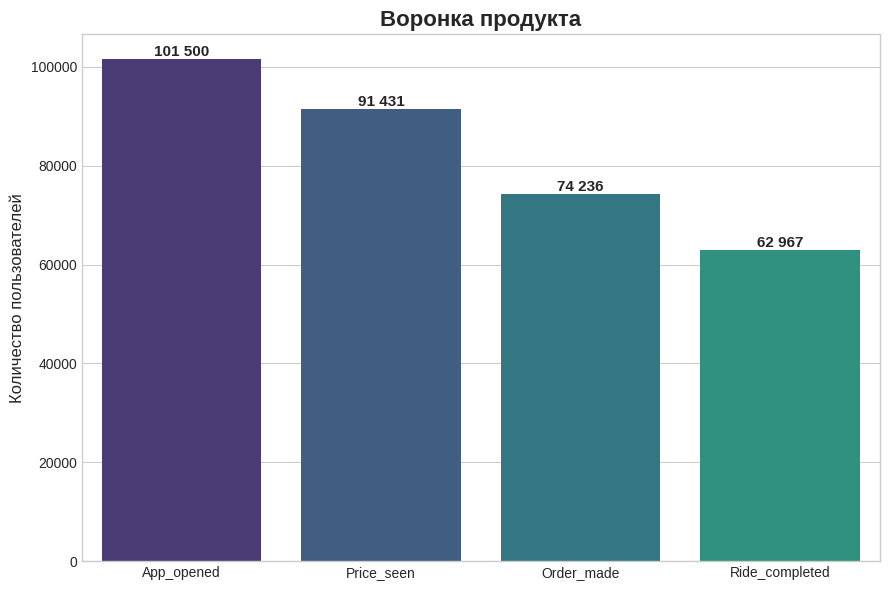


### 3. Процент отмен (общий и при Surge) ###
Общий процент отмен: 11.10%
surge
True    11.102463
Name: user_cancelled, dtype: float64

### 4. Конверсия в заказ: Центр vs Не центр ###
city_center_order
False    68.418631
True     76.675571
Name: order_made, dtype: float64

### 5. Распределение RFM сегментов ###
rfm
low       50436
high      47267
medium     3797
Name: count, dtype: int64

### 6. Конверсия в заказ по возрастным группам ###
age_bin
<18      74.341984
18-25    73.361219
26-35    72.772660
36-45    73.390850
46-60    70.300628
60+      23.841060
Name: order_made, dtype: float64


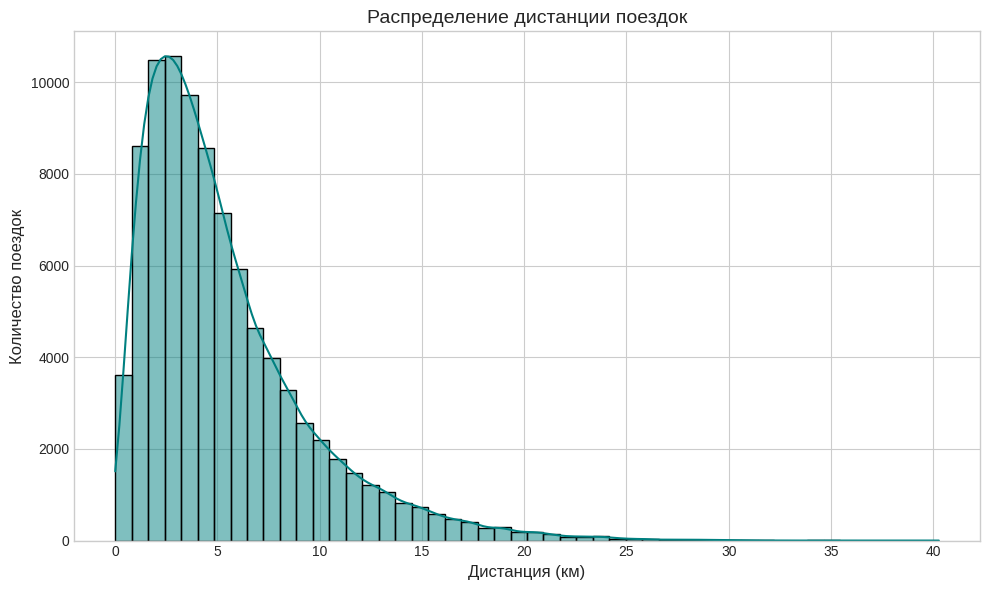

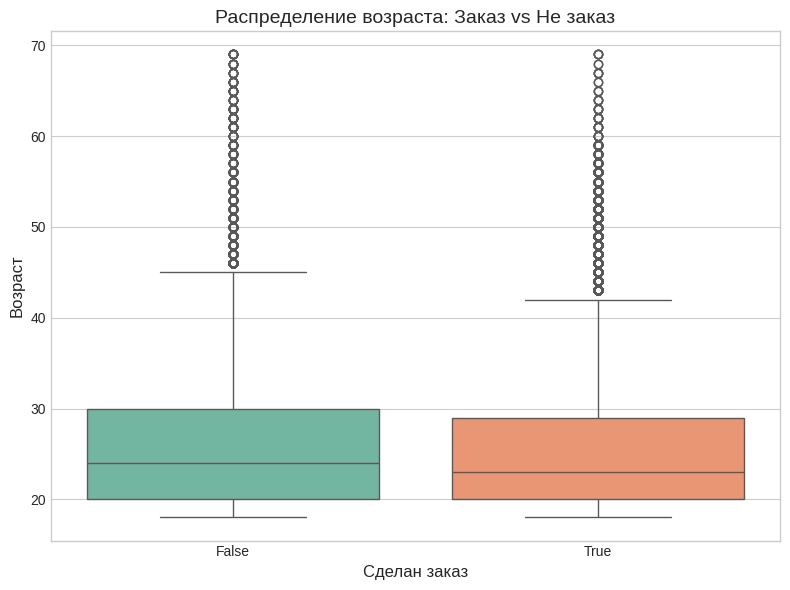

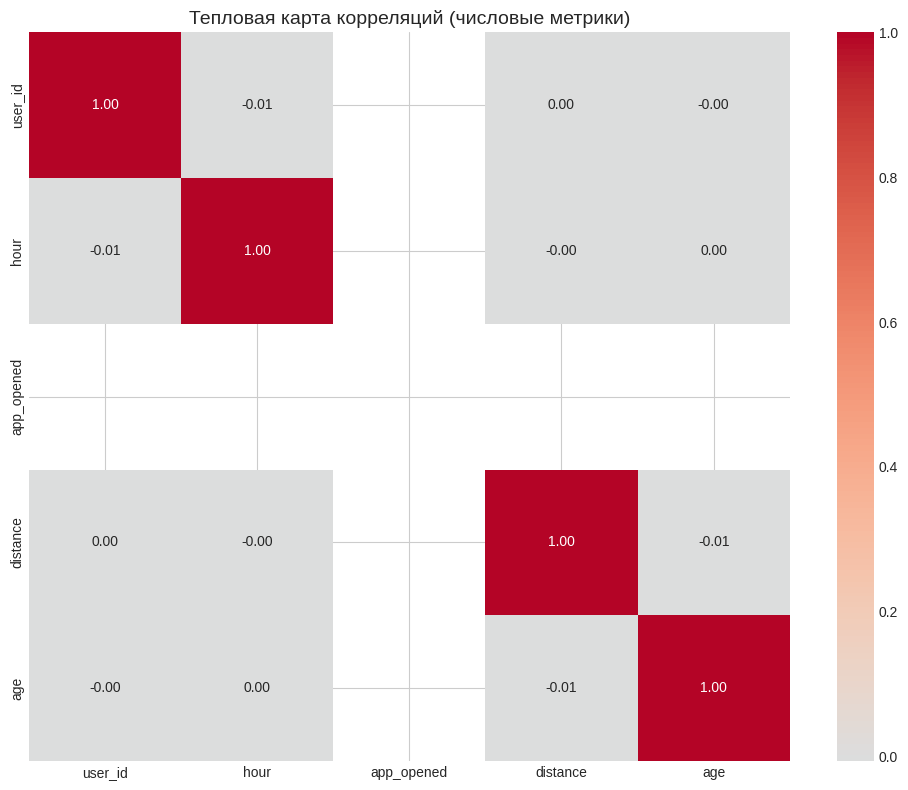


### 7. Сформулированные SMART-гипотезы ###
   №                                Гипотеза  Оценка
0  1                Прозрачная причина Surge       8
1  2           Персональный промокод для RFM       9
2  3  Кнопка "Вызвать такси за меня" для 60+       7
3  4               Перенос кнопки выше сгиба       6
4  5  Кнопка "Заказать эту же поездку снова"       8

### 8. Приоритизация по ICE (бонус) ###
                             Гипотеза  ICE_Score
0                Повторный заказ (№5)        384
1  Персональный промокод для RFM (№2)        320
2       Прозрачная причина Surge (№1)        315

✅ Таблица с гипотезами сохранена в файл 'hypotheses_for_template.xlsx'

✅ Исходные данные для графиков выгружены в 'exports/graph_data_source.xlsx'
✅ Все графики сохранены в папку 'exports' в виде PNG.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Настройка стиля графиков для читаемости
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# --- 1. Загрузка данных (БЕЗ ОЧИСТКИ) ---
try:
    df = pd.read_excel('new_dataframe.xlsx')
except FileNotFoundError:
    print("Файл 'new_dataframe.xlsx' не найден. Загрузите его в корень среды Colab через вкладку 'Файлы' (слева).")
    df = None
except Exception as e:
    print(f"Ошибка при чтении файла: {e}")
    df = None

if df is not None:
    # --- ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (EDA) ДО ОЧИСТКИ ---
    print("=" * 70)
    print("ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (ДО ОЧИСТКИ И ТРАНСФОРМАЦИЙ)")
    print("=" * 70)

    # 1. Вид и размер (Shape)
    print(f"\n### 1. Размер датафрейма ###")
    print(f"Строк (сессий/записей): {df.shape[0]:,}")
    print(f"Столбцов (фичей): {df.shape[1]}")

    # 2. Информация о колонках (Dtypes)
    print("\n### 2. Типы данных столбцов (сырые данные) ###")
    print(df.dtypes)

    # 3. Реальные названия колонок
    print("\n### 3. Реальные названия колонок в файле ###")
    print(df.columns.tolist())

    # 4. Период данных
    date_col = None
    for col in df.columns:
        if 'date' in col.lower() or 'time' in col.lower() or 'hour' in col.lower():
            date_col = col
            break

    if date_col:
        print(f"\n### 4. Период данных (по колонке '{date_col}') ###")
        print(f"Первые 5 значений: {df[date_col].head().tolist()}")
        try:
            temp_dates = pd.to_datetime(df[date_col], errors='coerce')
            if not temp_dates.isnull().all():
                min_date = temp_dates.min().date()
                max_date = temp_dates.max().date()
                print(f"Дата начала (после парсинга): {min_date}")
                print(f"Дата окончания (после парсинга): {max_date}")
                duration = max_date - min_date
                print(f"Длительность периода: {duration.days + 1} дней")
            else:
                print("Дату распознать не удалось (все значения превратились в NaT).")
        except Exception as e:
            print(f"Ошибка при попытке парсинга даты: {e}")
    else:
        print("\n### 4. Период данных ###")
        print("Колонка с датой или временем не найдена в названиях столбцов.")

    # 5. Пропуски в данных (ИСПРАВЛЕНО: np.prod вместо np.product)
    print("\n### 5. Пропуски в данных (сырые данные) ###")
    missing_stats = df.isnull().sum()
    total_cells = np.prod(df.shape)
    if total_cells > 0:
        missing_percent = (missing_stats.sum() / total_cells) * 100
        print(f"Общий процент пропусков в датасете: {missing_percent:.2f}%")
    else:
        print("Датасет пуст, расчет пропусков невозможен.")

    missing_filtered = missing_stats[missing_stats > 0].sort_values(ascending=False)
    if not missing_filtered.empty:
        print("\nКолонки с пропусками:")
        print(missing_filtered)
    else:
        print("\nПропусков в данных нет.")

    # 6. Дубликаты
    print("\n### 6. Дубликаты ###")
    dup_count = df.duplicated().sum()
    print(f"Количество полностью дублирующихся строк: {dup_count:,}")

    # 7. Статистика по числовым колонкам
    print("\n### 7. Статистика по числовым колонкам ###")
    print(df.describe(include=[np.number]))

    # --- ОЧИСТКА ДАННЫХ ---
    print("\n" + "="*70)
    print("ОЧИСТКА И ТРАНСФОРМАЦИЯ ДАННЫХ")
    print("="*70)

    clean_cols = {col: col.strip().lower().replace(' ', '_') for col in df.columns}
    df.rename(columns=clean_cols, inplace=True)

    bool_cols = [col for col in df.columns if df[col].dtype == 'bool' or df[col].nunique() == 2]
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype('bool')

    # --- ДАЛЬНЕЙШИЙ АНАЛИЗ ---
    required_cols = ['app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'surge', 'city_center_order', 'distance', 'age', 'rfm']

    if all(col in df.columns for col in required_cols):
        print("\n" + "="*70)
        print("АНАЛИЗ ВОРОНКИ И МЕТРИК")
        print("="*70)

        print("### 1. Воронка конверсии (в абсолютных числах) ###")
        funnel = {
            'App_opened': df['app_opened'].sum(),
            'Price_seen': df['price_seen'].sum(),
            'Order_made': df['order_made'].sum(),
            'Ride_completed': df['ride_completed'].sum()
        }
        print(funnel)

        print("\n### 2. Воронка конверсии (в процентах) ###")
        funnel_rates = {
            'App -> Price': (funnel['Price_seen'] / funnel['App_opened'] * 100) if funnel['App_opened'] > 0 else 0,
            'Price -> Order': (funnel['Order_made'] / funnel['Price_seen'] * 100) if funnel['Price_seen'] > 0 else 0,
            'Order -> Complete': (funnel['Ride_completed'] / funnel['Order_made'] * 100) if funnel['Order_made'] > 0 else 0
        }
        for k, v in funnel_rates.items():
            print(f"{k}: {v:.2f}%")

        # --- ВИЗУАЛИЗАЦИЯ ---
        os.makedirs('exports', exist_ok=True)

        plt.figure(figsize=(9, 6))
        sns.barplot(x=list(funnel.keys()), y=list(funnel.values()), hue=list(funnel.keys()), legend=False)
        plt.title('Воронка продукта', fontsize=16, weight='bold')
        plt.ylabel('Количество пользователей', fontsize=12)
        plt.xlabel('')
        for i, v in enumerate(funnel.values()):
            plt.text(i, v, f"{v:,}".replace(',', ' '), ha='center', va='bottom', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('exports/funnel_graph.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n### 3. Процент отмен (общий и при Surge) ###")
        overall_cancel_rate = df['user_cancelled'].mean() * 100
        print(f"Общий процент отмен: {overall_cancel_rate:.2f}%")

        surge_cancel = df.groupby('surge', observed=True)['user_cancelled'].mean() * 100
        if not surge_cancel.empty:
            print(surge_cancel)
        else:
            print("Данных для сравнения Surge (True/False) недостаточно.")

        print("\n### 4. Конверсия в заказ: Центр vs Не центр ###")
        center_order_rate = df.groupby('city_center_order', observed=True)['order_made'].mean() * 100
        print(center_order_rate)

        print("\n### 5. Распределение RFM сегментов ###")
        rfm_counts = df['rfm'].value_counts()
        print(rfm_counts)

        print("\n### 6. Конверсия в заказ по возрастным группам ###")
        df['age_bin'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 60, 120], labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+'])
        age_order_rate = df.groupby('age_bin', observed=True)['order_made'].mean() * 100
        print(age_order_rate)

        # --- ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ ---

        plt.figure(figsize=(10, 6))
        sns.histplot(df['distance'].dropna(), bins=50, kde=True, color='teal')
        plt.title('Распределение дистанции поездок', fontsize=14)
        plt.xlabel('Дистанция (км)', fontsize=12)
        plt.ylabel('Количество поездок', fontsize=12)
        plt.tight_layout()
        plt.savefig('exports/distance_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

        plt.figure(figsize=(8, 6))
        # ИСПРАВЛЕНО: добавлен hue для устранения FutureWarning
        sns.boxplot(x='order_made', y='age', hue='order_made', data=df, palette='Set2', legend=False)
        plt.title('Распределение возраста: Заказ vs Не заказ', fontsize=14)
        plt.xlabel('Сделан заказ', fontsize=12)
        plt.ylabel('Возраст', fontsize=12)
        plt.tight_layout()
        plt.savefig('exports/age_boxplot.png', dpi=300, bbox_inches='tight')
        plt.show()

        num_cols = df.select_dtypes(include=np.number).columns
        plt.figure(figsize=(10, 8))
        corr_matrix = df[num_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
        plt.title('Тепловая карта корреляций (числовые метрики)', fontsize=14)
        plt.tight_layout()
        plt.savefig('exports/correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

        # --- ФОРМИРОВАНИЕ ГИПОТЕЗ ---
        hypotheses_data = [
            {'№': 1, 'Гипотеза': 'Прозрачная причина Surge', 'Оценка': 8},
            {'№': 2, 'Гипотеза': 'Персональный промокод для RFM', 'Оценка': 9},
            {'№': 3, 'Гипотеза': 'Кнопка "Вызвать такси за меня" для 60+', 'Оценка': 7},
            {'№': 4, 'Гипотеза': 'Перенос кнопки выше сгиба', 'Оценка': 6},
            {'№': 5, 'Гипотеза': 'Кнопка "Заказать эту же поездку снова"', 'Оценка': 8}
        ]
        hypotheses_df = pd.DataFrame(hypotheses_data)
        print("\n### 7. Сформулированные SMART-гипотезы ###")
        print(hypotheses_df[['№', 'Гипотеза', 'Оценка']])

        ice_data = [
            {'Гипотеза': 'Прозрачная причина Surge (№1)', 'Impact': 9, 'Confidence': 7, 'Ease': 5},
            {'Гипотеза': 'Персональный промокод для RFM (№2)', 'Impact': 10, 'Confidence': 8, 'Ease': 4},
            {'Гипотеза': 'Повторный заказ (№5)', 'Impact': 8, 'Confidence': 8, 'Ease': 6}
        ]
        ice_df = pd.DataFrame(ice_data)
        ice_df['ICE_Score'] = ice_df['Impact'] * ice_df['Confidence'] * ice_df['Ease']
        ice_df = ice_df.sort_values('ICE_Score', ascending=False).reset_index(drop=True)
        print("\n### 8. Приоритизация по ICE (бонус) ###")
        print(ice_df[['Гипотеза', 'ICE_Score']])

        os.makedirs('exports', exist_ok=True)
        hypotheses_df.to_excel('hypotheses_for_template.xlsx', index=False)
        print("\n✅ Таблица с гипотезами сохранена в файл 'hypotheses_for_template.xlsx'")

        with pd.ExcelWriter('exports/graph_data_source.xlsx') as writer:
            pd.DataFrame({'Этап': list(funnel.keys()), 'Пользователи': list(funnel.values())}).to_excel(writer, sheet_name='Funnel', index=False)
            df.groupby('surge', observed=True)['user_cancelled'].mean().reset_index().to_excel(writer, sheet_name='Surge_Cancel', index=False)
            df.groupby('city_center_order', observed=True)['order_made'].mean().reset_index().to_excel(writer, sheet_name='Center_Order', index=False)
            df.groupby('age_bin', observed=True)['order_made'].mean().reset_index().to_excel(writer, sheet_name='Age_Conversion', index=False)
            df['rfm'].value_counts().reset_index().to_excel(writer, sheet_name='RFM_Distribution', index=False)
            df[['distance']].describe().to_excel(writer, sheet_name='Distance_Stats', index=False)

        print("\n✅ Исходные данные для графиков выгружены в 'exports/graph_data_source.xlsx'")
        print("✅ Все графики сохранены в папку 'exports' в виде PNG.")

    else:
        print("\nОШИБКА: Для анализа воронки не хватает колонок.")
        print(f"Ожидались: {required_cols}")
        print(f"Найдены: {df.columns.tolist()}")
else:
    print("Анализ прерван из-за ошибки загрузки файла.")